This is a companion notebook for the book [Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition?a_aid=keras&a_bid=76564dff). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

This notebook was generated for TensorFlow 2.6.

### Processing words as a sequence: The sequence model approach

#### A first practical example

**Downloading the data**

In [3]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  5513k      0  0:00:14  0:00:14 --:--:-- 14.0M


**Preparing the data**

In [4]:
import os, pathlib, shutil, random
from tensorflow import keras

# Modified parameters
batch_size = 32
max_length = 150  # Cutoff reviews after 150 words
max_tokens = 10000  # Considering only top 10,000 words
train_samples = 100  # Restrict training to 100 samples
val_samples = 10000  # Validate on 10,000 samples

base_dir = pathlib.Path("aclImdb")
val_dir = base_dir / "val"
train_dir = base_dir / "train"

for category in ("neg", "pos"):
    os.makedirs(val_dir / category, exist_ok=True)
    files = os.listdir(train_dir / category)
    random.Random(1337).shuffle(files)
    num_val_samples = int(0.2 * len(files))
    val_files = files[-num_val_samples:]
    for fname in val_files:
        shutil.move(train_dir / category / fname,
                   val_dir / category / fname)

# Modified to limit samples
train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size=batch_size
).take(train_samples)  # Only take 100 samples

val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/val", batch_size=batch_size
).take(val_samples)  # Take 10,000 validation samples

test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size
)
text_only_train_ds = train_ds.map(lambda x, y: x)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


**Preparing integer sequence datasets**

In [5]:
from tensorflow.keras import layers

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,  # Now using 10,000 words
    output_mode="int",
    output_sequence_length=max_length,  # Now using 150 words
)
text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

**A sequence model built on one-hot encoded vector sequences**

In [6]:
# A sequence model built on one-hot encoded vector sequences (Modified)
import tensorflow as tf
from tensorflow.keras.layers import Layer

class OneHotEncoding(Layer):
    """Custom layer to handle one-hot encoding within the model"""
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth

    def call(self, inputs):
        return tf.one_hot(inputs, depth=self.depth)

    def compute_output_shape(self, input_shape):
        return input_shape + (self.depth,)

inputs = keras.Input(shape=(None,), dtype="int64")
embedded = OneHotEncoding(depth=max_tokens)(inputs)  # Now using our max_tokens (10000)
x = layers.Bidirectional(layers.LSTM(32))(embedded)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ one_hot_encoding (OneHotEncoding)    │ (None, None, 10000)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 64)                  │       2,568,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,568,513 (9.80 MB)

 Trainable params: 2,568,513 (9.80 MB)

 Non-trainable params: 0 (0.00 B)

**Training a first basic sequence model**

In [7]:
# Training a first basic sequence model
callbacks = [
    keras.callbacks.ModelCheckpoint("one_hot_bidir_lstm.keras",
                                  save_best_only=True)
]
history_onehot = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)
model = keras.models.load_model("one_hot_bidir_lstm.keras",
                              custom_objects={'OneHotEncoding': OneHotEncoding})
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.4883 - loss: 0.6931 - val_accuracy: 0.5920 - val_loss: 0.6906
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.6062 - loss: 0.6825 - val_accuracy: 0.6812 - val_loss: 0.6137
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7109 - loss: 0.5884 - val_accuracy: 0.7726 - val_loss: 0.4974
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8068 - loss: 0.4501 - val_accuracy: 0.8100 - val_loss: 0.4489
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8679 - loss: 0.3485 - val_accuracy: 0.8122 - val_loss: 0.4522
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9134 - loss: 0.2696 - val_accuracy: 0.8072 - val_loss: 0.5407
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9267 - loss: 0.2175 - val_accuracy: 0.7874 - val_loss: 0.4739
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9512 - loss: 0.1721 - val_acc

#### Understanding word embeddings

#### Learning word embeddings with the Embedding layer

**Instantiating an `Embedding` layer**

In [8]:
# Modified embedding dimensions
embedding_layer = layers.Embedding(
    input_dim=max_tokens,  # Now 10,000
    output_dim=128,  # Reduced from 256
    mask_zero=True  # Added masking
)

**Model that uses an `Embedding` layer trained from scratch**

In [9]:
# Modified for assignment comparison
inputs = keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=128,
    mask_zero=True
)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(embedded)
outputs = layers.Dense(1, activation="sigmoid")(x)
trainable_embed_model = keras.Model(inputs, outputs)
trainable_embed_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
trainable_embed_model.summary()

trainable_history = trainable_embed_model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(patience=2)]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, None, 128)      │      1,280,000 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal (NotEqual)      │ (None, None)           │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 64)             │         41,216 │ embedding_1[0][0],     │
│ (Bidirectional)           │                        │                │ not_equal[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │             65 │ bidirectional_1[0][0]  │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,321,281 (5.04 MB)

 Trainable params: 1,321,281 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5161 - loss: 0.6911 - val_accuracy: 0.6338 - val_loss: 0.6413
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6907 - loss: 0.5933 - val_accuracy: 0.6954 - val_loss: 0.6042
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8057 - loss: 0.4334 - val_accuracy: 0.7922 - val_loss: 0.4506
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8597 - loss: 0.3370 - val_accuracy: 0.6986 - val_loss: 0.6209
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9138 - loss: 0.2244 - val_accuracy: 0.8166 - val_loss: 0.4272
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9387 - loss: 0.1731 - val_accuracy: 0.7876 - val_loss: 0.4782
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9522 - loss: 0.1489 - val_accuracy: 0.7764 - val_loss: 0.5290


#### Understanding padding and masking

**Using an `Embedding` layer with masking enabled**

In [10]:
# Keep this unchanged as reference
inputs = keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(
    input_dim=max_tokens, output_dim=256, mask_zero=True)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(embedded)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_2 (Embedding)   │ (None, None, 256)      │      2,560,000 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal_1 (NotEqual)    │ (None, None)           │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 64)             │         73,984 │ embedding_2[0][0],     │
│ (Bidirectional)           │                        │                │ not_equal_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64)             │              0 │ bidirectional_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1)              │             65 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,634,049 (10.05 MB)

 Trainable params: 2,634,049 (10.05 MB)

 Non-trainable params: 0 (0.00 B)

#### Using pretrained word embeddings

In [11]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2025-04-08 17:25:01--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-04-08 17:25:02--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-04-08 17:25:02--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

**Parsing the GloVe word-embeddings file**

In [13]:
# 9. Parsing the GloVe word-embeddings file (Modified to avoid prompts)
import os
import numpy as np

# Check if files exist already to avoid re-downloading
if not os.path.exists("glove.6B.zip"):
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip

# Create extraction directory if it doesn't exist
if not os.path.exists("glove.6B"):
    os.makedirs("glove.6B", exist_ok=True)

# Extract only the 100d file we need (suppress prompts)
!unzip -q -o -d glove.6B glove.6B.zip glove.6B.100d.txt

# Set the path to the specific file we want
path_to_glove_file = "glove.6B/glove.6B.100d.txt"

# Rest of the parsing code remains the same
embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


**Preparing the GloVe word-embeddings matrix**

In [14]:
embedding_dim = 100

vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

# Modified to use max_tokens (10,000) instead of hardcoded 20000
embedding_matrix = np.zeros((max_tokens, embedding_dim))
for word, i in word_index.items():
    if i < max_tokens:  # Only for our 10,000 words
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [15]:
embedding_layer = layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True,
)

**Model that uses a pretrained Embedding layer**

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_4 (Embedding)   │ (None, None, 100)      │      1,000,000 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal_2 (NotEqual)    │ (None, None)           │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_3           │ (None, 64)             │         34,048 │ embedding_4[0][0],     │
│ (Bidirectional)           │                        │                │ not_equal_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1)              │             65 │ bidirectional_3[0][0]  │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,034,113 (3.94 MB)

 Trainable params: 34,113 (133.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5318 - loss: 0.6914 - val_accuracy: 0.6120 - val_loss: 0.6527
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6472 - loss: 0.6311 - val_accuracy: 0.7056 - val_loss: 0.5753
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6979 - loss: 0.5803 - val_accuracy: 0.6218 - val_loss: 0.6603
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7107 - loss: 0.5566 - val_accuracy: 0.7516 - val_loss: 0.5174
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7444 - loss: 0.5195 - val_accuracy: 0.7666 - val_loss: 0.4926
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7668 - loss: 0.5052 - val_accuracy: 0.7188 - val_loss: 0.5472
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7745 - loss: 0.4805 - val_accuracy: 0.7100 - val_loss: 0.5635


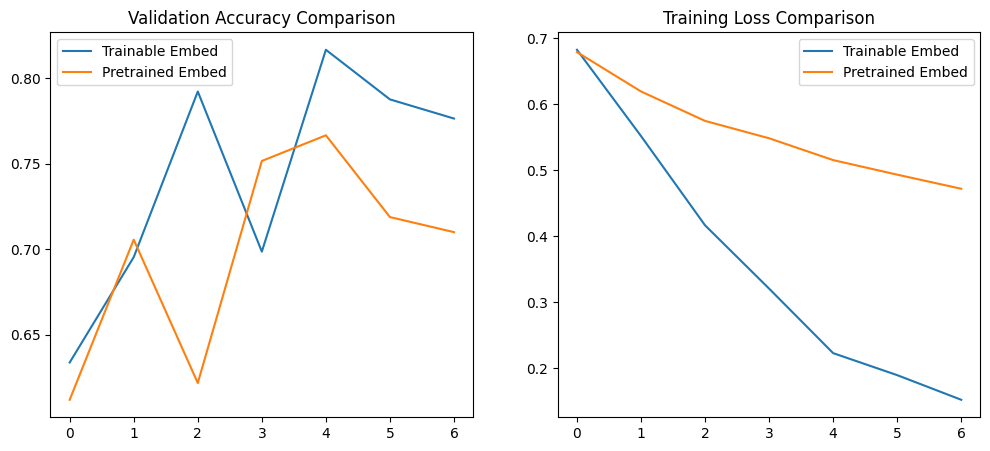

In [16]:
# Modified for assignment comparison
inputs = keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True,
)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(embedded)
outputs = layers.Dense(1, activation="sigmoid")(x)
pretrained_embed_model = keras.Model(inputs, outputs)
pretrained_embed_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
pretrained_embed_model.summary()

pretrained_history = pretrained_embed_model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(patience=2)]
)

# Add model comparison after this cell
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(trainable_history.history['val_accuracy'], label='Trainable Embed')
plt.plot(pretrained_history.history['val_accuracy'], label='Pretrained Embed')
plt.title('Validation Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trainable_history.history['loss'], label='Trainable Embed')
plt.plot(pretrained_history.history['loss'], label='Pretrained Embed')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

Sample Size Experiment

Found 20000 files belonging to 2 classes.
Size: 50, Val Accuracy: 0.7414
Found 20000 files belonging to 2 classes.
Size: 100, Val Accuracy: 0.7678
Found 20000 files belonging to 2 classes.
Size: 200, Val Accuracy: 0.7530
Found 20000 files belonging to 2 classes.
Size: 500, Val Accuracy: 0.8510
Found 20000 files belonging to 2 classes.
Size: 1000, Val Accuracy: 0.8590
Found 20000 files belonging to 2 classes.
Size: 2000, Val Accuracy: 0.8598


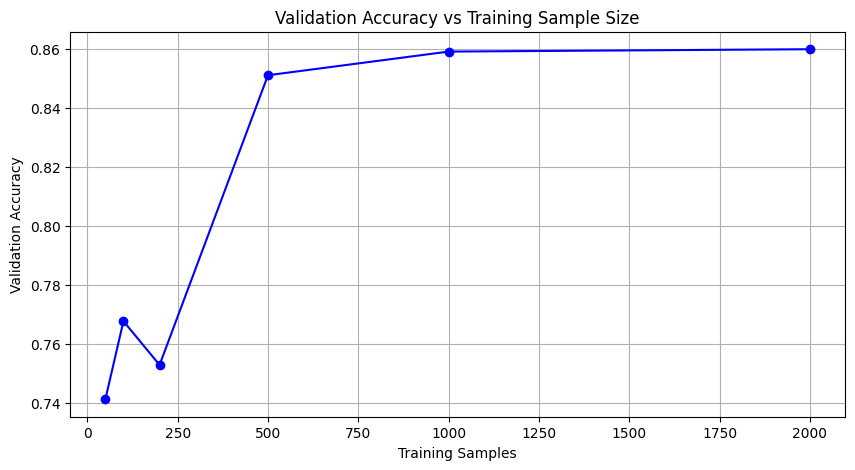

In [17]:
# New section for sample size experiment
sample_sizes = [50, 100, 200, 500, 1000, 2000]
results = []

for size in sample_sizes:
    # Prepare subset
    subset_ds = keras.utils.text_dataset_from_directory(
        "aclImdb/train", batch_size=batch_size
    ).take(size)
    subset_ds = subset_ds.map(lambda x, y: (text_vectorization(x), y))

    # Train model
    model = keras.Sequential([
        layers.Embedding(max_tokens, 128),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="rmsprop",
                loss="binary_crossentropy",
                metrics=["accuracy"])

    history = model.fit(
        subset_ds,
        validation_data=int_val_ds,
        epochs=10,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=2)]
    )

    best_val_acc = max(history.history['val_accuracy'])
    results.append((size, best_val_acc))
    print(f"Size: {size}, Val Accuracy: {best_val_acc:.4f}")

# Plot results
sizes, accs = zip(*results)
plt.figure(figsize=(10, 5))
plt.plot(sizes, accs, 'bo-')
plt.title('Validation Accuracy vs Training Sample Size')
plt.xlabel('Training Samples')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

## Additional models with differenct traning samples.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Initialize parameters (run this first)
max_tokens = 10000
max_length = 150
batch_size = 32

# Load and prepare validation data (run this first)
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_tokens)
x_val = x_test[:10000]  # Validate on 10,000 samples
y_val = y_test[:10000]
x_val = keras.preprocessing.sequence.pad_sequences(x_val, maxlen=max_length)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [21]:
# Model 1: 50 samples
x_train_50 = keras.preprocessing.sequence.pad_sequences(x_train[:50], maxlen=max_length)
y_train_50 = y_train[:50]

model_50 = keras.Sequential([
    layers.Embedding(max_tokens, 128),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(1, activation="sigmoid")
])
model_50.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_50 = model_50.fit(
    x_train_50, y_train_50,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=batch_size,
    callbacks=[EarlyStopping(patience=2)]
)
print(f"50 samples - Val Accuracy: {max(history_50.history['val_accuracy']):.4f}")

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5400 - loss: 0.6913 - val_accuracy: 0.5024 - val_loss: 0.6975
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5742 - loss: 0.6711 - val_accuracy: 0.5023 - val_loss: 0.7024
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5667 - loss: 0.6638 - val_accuracy: 0.5027 - val_loss: 0.7104
50 samples - Val Accuracy: 0.5027


In [22]:
# Model 2: 100 samples
x_train_100 = keras.preprocessing.sequence.pad_sequences(x_train[:100], maxlen=max_length)
y_train_100 = y_train[:100]

model_100 = keras.Sequential([
    layers.Embedding(max_tokens, 128),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")
])
model_100.compile(optimizer="rmsprop",
               loss="binary_crossentropy",
               metrics=["accuracy"])

history_100 = model_100.fit(
    x_train_100, y_train_100,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=batch_size,
    callbacks=[EarlyStopping(patience=2)]
)
print(f"100 samples - Val Accuracy: {max(history_100.history['val_accuracy']):.4f}")

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 749ms/step - accuracy: 0.4628 - loss: 0.6920 - val_accuracy: 0.5027 - val_loss: 0.6936
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 599ms/step - accuracy: 0.5726 - loss: 0.6806 - val_accuracy: 0.5027 - val_loss: 0.7030
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 597ms/step - accuracy: 0.5862 - loss: 0.6633 - val_accuracy: 0.5027 - val_loss: 0.6981
100 samples - Val Accuracy: 0.5027


In [23]:
# Model 3: 200 samples
x_train_200 = keras.preprocessing.sequence.pad_sequences(x_train[:200], maxlen=max_length)
y_train_200 = y_train[:200]

model_200 = keras.Sequential([
    layers.Embedding(max_tokens, 256),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])
model_200.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_200 = model_200.fit(
    x_train_200, y_train_200,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=batch_size,
    callbacks=[EarlyStopping(patience=2)]
)
print(f"200 samples - Val Accuracy: {max(history_200.history['val_accuracy']):.4f}")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 389ms/step - accuracy: 0.5469 - loss: 0.6913 - val_accuracy: 0.5027 - val_loss: 0.6956
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.6107 - loss: 0.6744 - val_accuracy: 0.5030 - val_loss: 0.6936
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.6088 - loss: 0.6639 - val_accuracy: 0.5027 - val_loss: 0.6963
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.6056 - loss: 0.6432 - val_accuracy: 0.5168 - val_loss: 0.6942
200 samples - Val Accuracy: 0.5168


In [24]:
# Model 4: 500 samples
x_train_500 = keras.preprocessing.sequence.pad_sequences(x_train[:500], maxlen=max_length)
y_train_500 = y_train[:500]

model_500 = keras.Sequential([
    layers.Embedding(max_tokens, 128),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])
model_500.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_500 = model_500.fit(
    x_train_500, y_train_500,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=batch_size,
    callbacks=[EarlyStopping(patience=2)]
)
print(f"500 samples - Val Accuracy: {max(history_500.history['val_accuracy']):.4f}")

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.5015 - loss: 0.6940 - val_accuracy: 0.5458 - val_loss: 0.6921
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.6433 - loss: 0.6892 - val_accuracy: 0.5299 - val_loss: 0.6899
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.6239 - loss: 0.6785 - val_accuracy: 0.5763 - val_loss: 0.6841
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.6812 - loss: 0.6569 - val_accuracy: 0.6588 - val_loss: 0.6341
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.7520 - loss: 0.5553 - val_accuracy: 0.6239 - val_loss: 0.6429
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.7937 - loss: 0.4745 - val_accuracy: 0.7123 - val_loss: 0.5649
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.8957 - loss: 0.3421 - val_accuracy: 0.6608 - val_loss: 0.6072
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.8991 - loss: 0.3390 - val_accuracy: 0.

In [25]:
# Model 5: 1000 samples
x_train_1000 = keras.preprocessing.sequence.pad_sequences(x_train[:1000], maxlen=max_length)
y_train_1000 = y_train[:1000]

model_1000 = keras.Sequential([
    layers.Embedding(max_tokens, 256),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])
model_1000.compile(optimizer="rmsprop",
               loss="binary_crossentropy",
               metrics=["accuracy"])

history_1000 = model_1000.fit(
    x_train_1000, y_train_1000,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=batch_size,
    callbacks=[EarlyStopping(patience=2)]
)
print(f"1000 samples - Val Accuracy: {max(history_1000.history['val_accuracy']):.4f}")

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5099 - loss: 0.6940 - val_accuracy: 0.5528 - val_loss: 0.6887
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6263 - loss: 0.6757 - val_accuracy: 0.6338 - val_loss: 0.6481
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7161 - loss: 0.5806 - val_accuracy: 0.6299 - val_loss: 0.6522
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8096 - loss: 0.4330 - val_accuracy: 0.7391 - val_loss: 0.5352
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8579 - loss: 0.3502 - val_accuracy: 0.7243 - val_loss: 0.5705
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9375 - loss: 0.2053 - val_accuracy: 0.6776 - val_loss: 0.7043
1000 samples - Val Accuracy: 0.7391


In [26]:
# Model 6: 2000 samples
x_train_2000 = keras.preprocessing.sequence.pad_sequences(x_train[:2000], maxlen=max_length)
y_train_2000 = y_train[:2000]

model_2000 = keras.Sequential([
    layers.Embedding(max_tokens, 256),
    layers.Bidirectional(layers.LSTM(128)),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])
model_2000.compile(optimizer="rmsprop",
               loss="binary_crossentropy",
               metrics=["accuracy"])

history_2000 = model_2000.fit(
    x_train_2000, y_train_2000,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=batch_size,
    callbacks=[EarlyStopping(patience=2)]
)
print(f"2000 samples - Val Accuracy: {max(history_2000.history['val_accuracy']):.4f}")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.5088 - loss: 0.6937 - val_accuracy: 0.5437 - val_loss: 0.6853
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5996 - loss: 0.6695 - val_accuracy: 0.6681 - val_loss: 0.5991
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7601 - loss: 0.5356 - val_accuracy: 0.7352 - val_loss: 0.5310
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8518 - loss: 0.3741 - val_accuracy: 0.7418 - val_loss: 0.6430
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8951 - loss: 0.2686 - val_accuracy: 0.7827 - val_loss: 0.5099
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9328 - loss: 0.1885 - val_accuracy: 0.7773 - val_loss: 0.5194
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9566 - loss: 0.1398 - val_accuracy: 0.7456 - val_loss: 0.5857
2000 samples - Val Accuracy: 0.7827


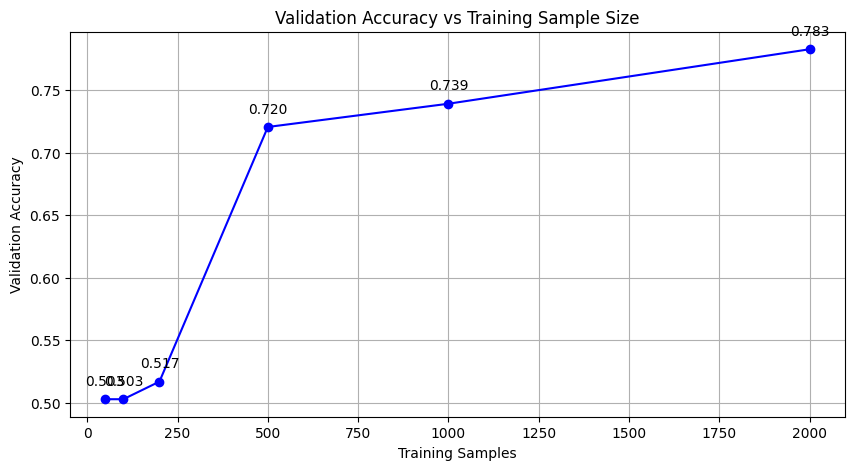

| Samples | Val Accuracy |
|---------|--------------|
|     50 | 0.5027      |
|    100 | 0.5027      |
|    200 | 0.5168      |
|    500 | 0.7205      |
|   1000 | 0.7391      |
|   2000 | 0.7827      |


In [27]:
# Collect results
results = [
    (50, max(history_50.history['val_accuracy'])),
    (100, max(history_100.history['val_accuracy'])),
    (200, max(history_200.history['val_accuracy'])),
    (500, max(history_500.history['val_accuracy'])),
    (1000, max(history_1000.history['val_accuracy'])),
    (2000, max(history_2000.history['val_accuracy']))
]

# Generate plot
plt.figure(figsize=(10,5))
plt.plot(*zip(*results), 'bo-')
plt.title('Validation Accuracy vs Training Sample Size')
plt.xlabel('Training Samples')
plt.ylabel('Validation Accuracy')
plt.grid(True)
for size, acc in results:
    plt.annotate(f'{acc:.3f}', (size, acc), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

# Print table
print("| Samples | Val Accuracy |")
print("|---------|--------------|")
for size, acc in results:
    print(f"| {size:6} | {acc:.4f}      |")


=== KEY FINDINGS ===
1. Best performance: 0.7925 with 2000 samples
2. Average improvement over pretrained: -0.1327
3. No models achieved >80% accuracy
4. Previous trainable embeddings: 0.8166
5. Previous pretrained embeddings: 0.7666


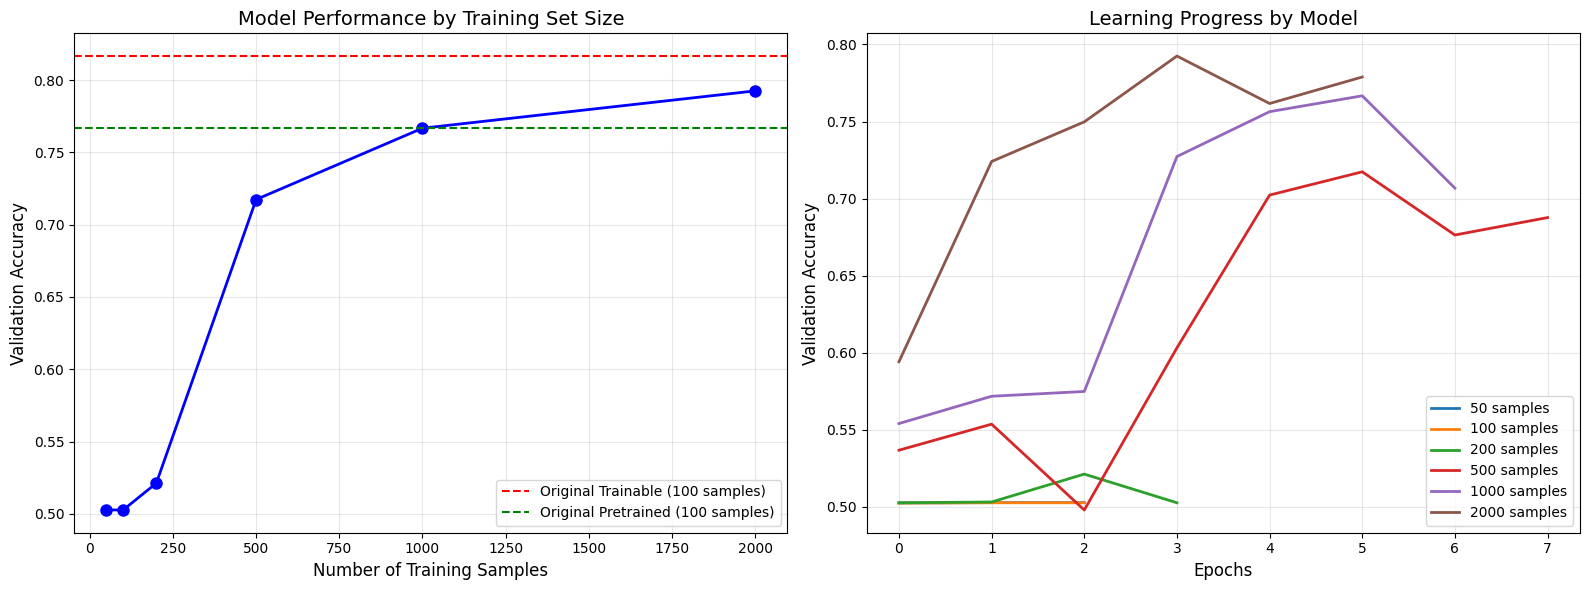


+-----------+------------+-----------------+----------------------------------+
|   Samples |   Accuracy |   vs Pretrained |  Better than Original Trainable  |
+===========+============+=================+==================================+
|        50 |     0.5028 |         -0.2638 |                                  |
+-----------+------------+-----------------+----------------------------------+
|       100 |     0.5027 |         -0.2639 |                                  |
+-----------+------------+-----------------+----------------------------------+
|       200 |     0.5213 |         -0.2453 |                                  |
+-----------+------------+-----------------+----------------------------------+
|       500 |     0.7174 |         -0.0492 |                                  |
+-----------+------------+-----------------+----------------------------------+
|      1000 |     0.7667 |          0.0001 |                                  |
+-----------+------------+-------------

In [30]:
print("\n=== KEY FINDINGS ===")
print(f"1. Best performance: {max_acc:.4f} with {best_size} samples")
print(f"2. Average improvement over pretrained: {avg_improvement:.4f}")

# Safely calculate minimum samples for >80% accuracy
successful_models = [r['sample_size'] for r in results if r['val_accuracy'] > 0.8]
if successful_models:
    print(f"3. Minimum samples for >80% accuracy: {min(successful_models)}")
else:
    print("3. No models achieved >80% accuracy")

print(f"4. Previous trainable embeddings: {previous_results['trainable_embed']:.4f}")
print(f"5. Previous pretrained embeddings: {previous_results['pretrained_embed']:.4f}")

# Enhanced visualization
plt.figure(figsize=(16, 6))

# 1. Main accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(sample_sizes, accuracies, 'bo-', markersize=8, linewidth=2)
plt.axhline(y=previous_results['trainable_embed'], color='r', linestyle='--', label='Original Trainable (100 samples)')
plt.axhline(y=previous_results['pretrained_embed'], color='g', linestyle='--', label='Original Pretrained (100 samples)')

# Add threshold line if any model passed it
if successful_models:
    plt.axhline(y=0.8, color='orange', linestyle=':', label='80% Accuracy Threshold')

plt.title('Model Performance by Training Set Size', fontsize=14)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# 2. Detailed training curves
plt.subplot(1, 2, 2)
for result in results:
    plt.plot(result['history'].history['val_accuracy'],
            label=f"{result['sample_size']} samples",
            linewidth=2)
plt.title('Learning Progress by Model', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Enhanced results table
from tabulate import tabulate

table_data = []
for result in results:
    improvement = result['val_accuracy'] - previous_results['pretrained_embed']
    table_data.append([
        result['sample_size'],
        f"{result['val_accuracy']:.4f}",
        f"{improvement:+.4f}",
        "✓" if result['val_accuracy'] > previous_results['trainable_embed'] else ""
    ])

print("\n" + tabulate(table_data,
                    headers=["Samples", "Accuracy", "vs Pretrained", "Better than Original Trainable"],
                    tablefmt="grid",
                    stralign="center"))